In [4]:
import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))
# my utils
from utils import fa
from utils import modeling
from utils import preprocess_listings

# 标准版存档V0：
LABELS_EN=[
            'open to different cultures', 'cosmopolitan','international view', 'cultural exchange',
            'personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life',
            'meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction',
            'thoughtful service', 'attentive to needs', 'willing to help', 'responsive',
            'fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb'
        ]
DICT_FACTOR_ITEMS={"ouverture":['open to different cultures', 'cosmopolitan','international view', 'cultural exchange'],
                   "authenticité":['personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life'],
                   "sociabilité":['meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction'],
                   "auto_promotion":['thoughtful service', 'attentive to needs', 'willing to help', 'responsive'],
                   "exemplarité":['fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb']}


In [5]:
df_london=pd.read_csv("../data_processed_london\listings_london2406_bge_scores.csv")
df_paris=pd.read_csv("../data_processed_paris\listings_paris2406_bge_scores.csv")
df_all=pd.read_csv("../data_all\listings_paris_london2406.csv")

print(df_london.shape, df_paris.shape, df_all.shape)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_32464\1873810557.py:2: DtypeWarning: Columns (77,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df_paris=pd.read_csv("../data_processed_paris\listings_paris2406_bge_scores.csv")
C:\Users\yeliu\AppData\Local\Temp\ipykernel_32464\1873810557.py:3: DtypeWarning: Columns (68,77,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all=pd.read_csv("../data_all\listings_paris_london2406.csv")


(49856, 128) (62738, 128) (112594, 129)


In [6]:
# filtered by booking_rate_l90d
print(df_paris[['booking_rate_l90d_previousQ',"booking_rate_l90d"]].isna().value_counts(dropna=False)/len(df_paris))
print(df_paris[["number_of_reviews_till_previousQ",'number_of_reviews_thisQ','number_of_reviews_till_nextQ',"number_of_reviews_nextQ"]].isna().value_counts(dropna=False)/len(df_paris))
print(df_paris[["availability_90_previousQ","availability_90"]].isna().value_counts(dropna=False)/len(df_paris))


booking_rate_l90d_previousQ  booking_rate_l90d
False                        False                0.565957
True                         False                0.434043
Name: count, dtype: float64
number_of_reviews_till_previousQ  number_of_reviews_thisQ  number_of_reviews_till_nextQ  number_of_reviews_nextQ
False                             False                    False                         False                      1.0
Name: count, dtype: float64
availability_90_previousQ  availability_90
False                      False              0.751889
True                       False              0.248111
Name: count, dtype: float64


In [35]:
print('PARIS'.center(100,'-'))
# print(df_paris.columns.to_list())
# print(df_paris.status.value_counts(dropna=False)/len(df_paris),'\n')
# df_paris['no_change']=df_paris.apply(lambda row : 1 if row['status']=="old_host" and row["sp_changed"]==0 else 0, axis=1)
print(df_paris[['status','status_changed','sp_changed','old_host_sp_changed','is_changed']].value_counts(dropna=False)/len(df_paris))
## 不能认为新进入导致的sp_changed==1一定受到jo影响
# sp_changed/old_host_sp_changed二选一！


#****
print('LONDON'.center(100,'-'))
# print(df_london.columns.to_list())
# print(df_london.status.value_counts(dropna=False)/len(df_london),'\n')
# df_london['no_change']=df_london.apply(lambda row : 1 if row['status']=="old_host" and row["sp_changed"]==0 else 0, axis=1)
print(df_london[['status','status_changed','sp_changed','old_host_sp_changed',"is_changed"]].value_counts(dropna=False)/len(df_london))


-----------------------------------------------PARIS------------------------------------------------
status         status_changed  sp_changed  old_host_sp_changed  is_changed
old_host       0               0           0                    0             0.536214
reopen_host    1               0           0                    1             0.177357
reactive_host  1               1           0                    1             0.143438
old_host       0               1           1                    1             0.100067
new_host       1               1           0                    1             0.034349
reopen_host    1               1           0                    1             0.008575
Name: count, dtype: float64
-----------------------------------------------LONDON-----------------------------------------------
status         status_changed  sp_changed  old_host_sp_changed  is_changed
old_host       0               0           0                    0             0.703967
           

## desc

In [51]:
importlib.reload(preprocess_listings)
from utils.preprocess_listings import group_mean_table_ttest
OUTPUT_FOLDER_DESC=Path("../output_desc")
os.makedirs(OUTPUT_FOLDER_DESC, exist_ok=True)

cols_to_check=[
    # "host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating",'number_of_reviews',
    "years_since_host", "professional_host",#'calculated_host_listings_count',
    # "lang", "len",
    "price", "availability_30","availability_90", "room_type", "instant_bookable",
    "number_of_reviews_thisQ", "number_of_reviews_nextQ",
    "booking_rate_l90d_previousQ", "booking_rate_l90d",
    'is_changed', 'city'
]   
tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]

group_mean_table_ttest(df=df_all, #*
            cols_to_check=cols_to_check+tactics_vars, 
            group_col='status_changed', #*
            save=False, output_folder=OUTPUT_FOLDER_DESC, filename_noext=None)


#非常整齐的personal tactics 集中在为未改变的老房东？

[CHECK] ttest takes only 2 groups! OR go to ANOVA!
[INFO] groups :0 vs 1
[INFO] ttest on 112594 lines.

[WARNING]1 missing cols in df_input :
 number_of_reviews

[CHECK] ttest take ONLY numeric cols! 

[WARNING] no numeric cols:
 room_type; instant_bookable; city



d:\miniconda3\envs\airbnb_env\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
d:\miniconda3\envs\airbnb_env\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


status_changed,0,1,ttest_p,significance
proportion,0.73138,0.26862,NaN,NaN
review_scores_rating,4.738403,4.804358,0.0,***
years_since_host,6.674483,6.550736,0.000002,***
professional_host,0.56484,0.198975,0.0,***
price,242.194951,276.204497,0.0,***
availability_30,12.574239,8.057332,0.0,***
availability_90,52.515465,43.442718,0.0,***
number_of_reviews_thisQ,4.002514,3.57755,0.000822,***
number_of_reviews_nextQ,2.934765,1.971665,0.0,***
booking_rate_l90d_previousQ,0.131647,NaN,NaN,


## booking mod


### one city : paris

=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================

 ============================================basic model============================================= 

[NUMBER CHECK1] x_vars:12, x_vars_ctrl:12
[CHECK] isna False in all 13 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  host_is_superhost  lang   len    price  availability_90  room_type  instant_bookable  booking_rate_l90d
False                   False                 False                 False             False              False              False  False  False  False            False      False             False                31658
Name: count, dtype: int64

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_

,is_base,coef,se,t,pval,sig
f,True,-0.003922,0.002343,-1.673947,0.094151,
t,False,-0.003469,0.00347,-0.999634,0.317495,


authenticité
x f/t


,is_base,coef,se,t,pval,sig
f,True,0.007844,0.002526,3.105178,0.001903,**
t,False,0.005842,0.00392,1.4903,0.136155,


sociabilité
x f/t


...

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:748: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:748: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:748: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


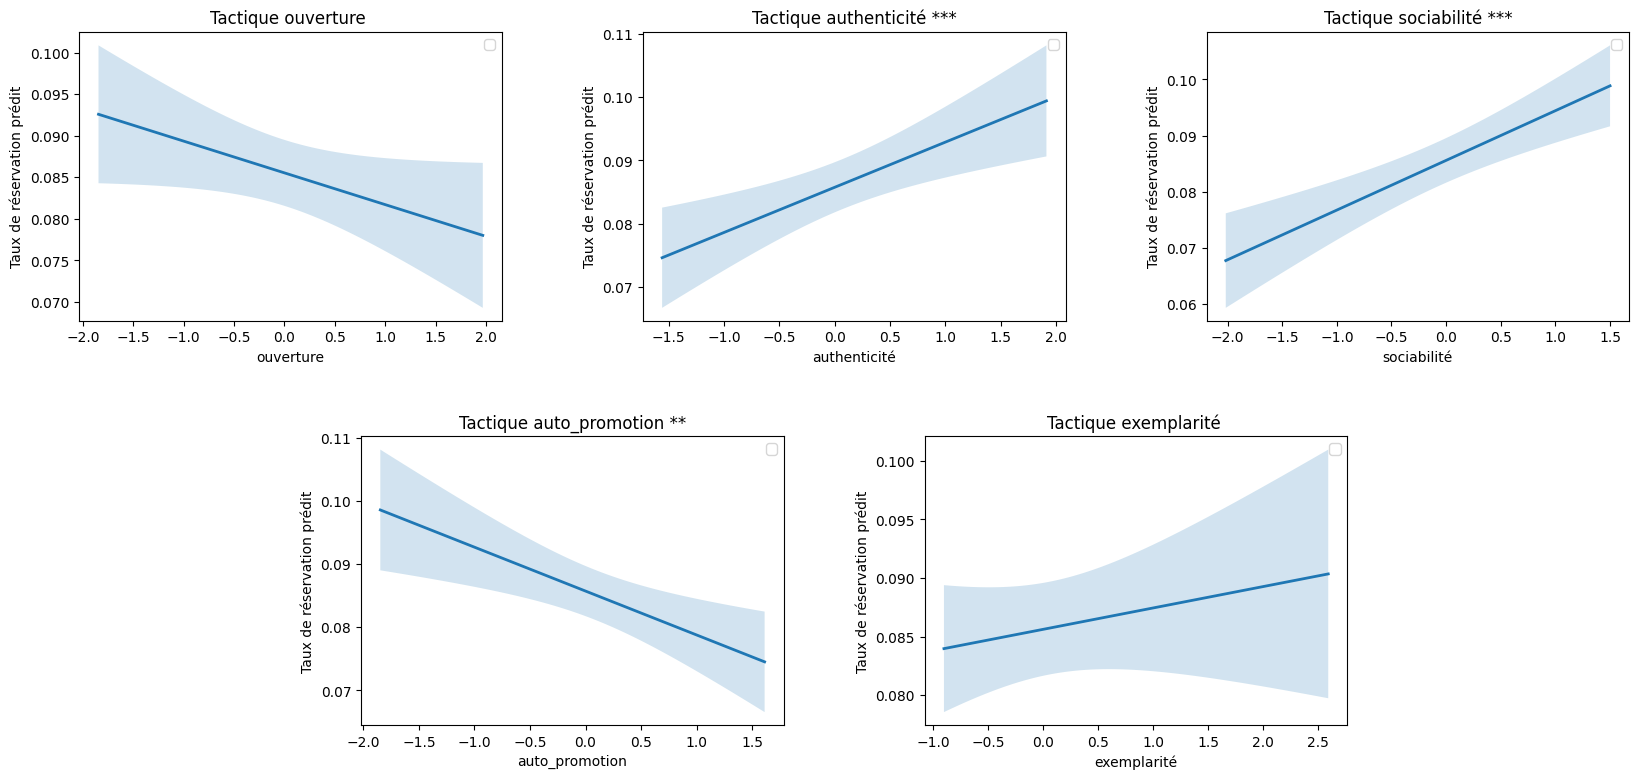

=========================================interaction plots==========================================
LIST group_col:['host_is_superhost']
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité + C(host_is_superhost) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

LIST group_col:['host_is_superhost']
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité + C(host_is_superhost) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

LIST group_col:['host_is_

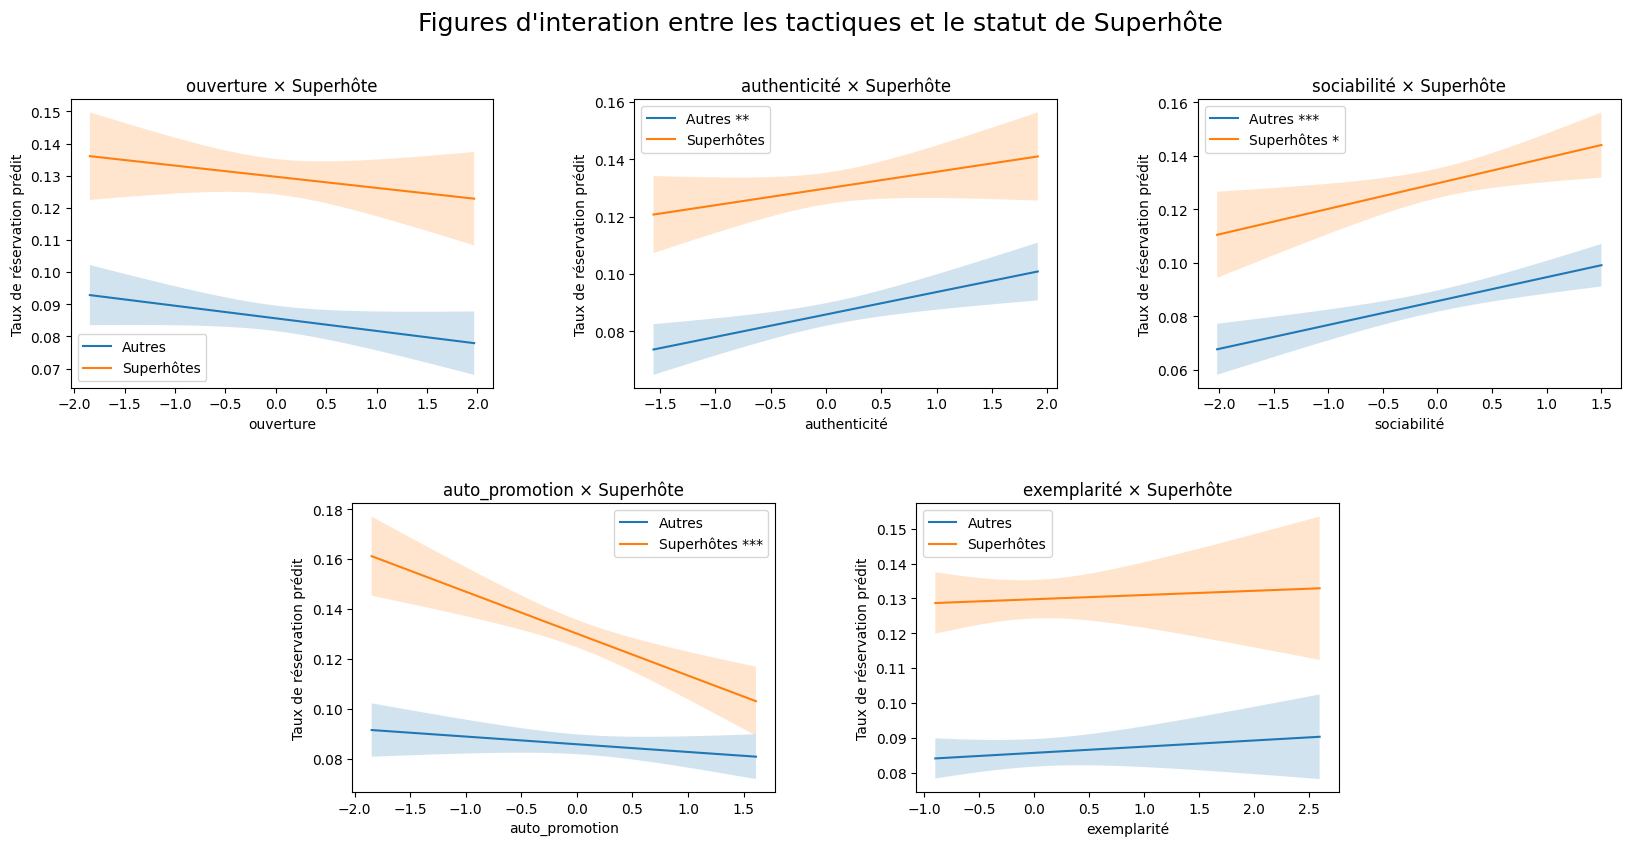

In [ ]:
importlib.reload(modeling)
from utils.modeling import modeling_main,build_model

#-------------------------------vars------------------------------------

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',# "is_changed"
    "lang", "len",
    "price",
    "availability_90",#*
    "room_type", "instant_bookable", #'is_within_1km',#"city"
]  
tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]


#-------------------------------output------------------------------------
# OUTPUT_FOLDER_MOD=Path("../output_mod_paris/booking90-status")
df_paris2312=pd.read_csv("../data_processed_paris2312/listings_paris2312_filtered90.csv")

modeling_main(df_input=df_paris2312, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col='host_is_superhost',#==stauts_changed+sp_changed
            output_folder=None,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )

# is_changed 作为交互项没有显著性，说明不能只改变，需要进行特殊类型的改变？
# 除了autopromotion，superhost&autres之间没有显著差异
##

=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================

 ============================================basic model============================================= 

[NUMBER CHECK1] x_vars:13, x_vars_ctrl:13
[CHECK] isna False in all 14 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  host_is_superhost  status_changed  lang   len    price  availability_90  room_type  instant_bookable  booking_rate_l90d
False                   False                 False                 False             False              False              False           False  False  False  False            False      False             False                62738
Name: count, dtype: int64

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_i

,is_base,coef,se,t,pval,sig
0,True,-0.005213,0.001373,-3.795921,0.000147,***
1,True,-0.005213,0.001373,-3.795921,0.000147,***


authenticité
x 0/1


,is_base,coef,se,t,pval,sig
0,True,0.006308,0.001536,4.106887,0.00004,***
1,True,0.006308,0.001536,4.106887,0.00004,***


sociabilité
x 0/1


...

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:696: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:696: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:696: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


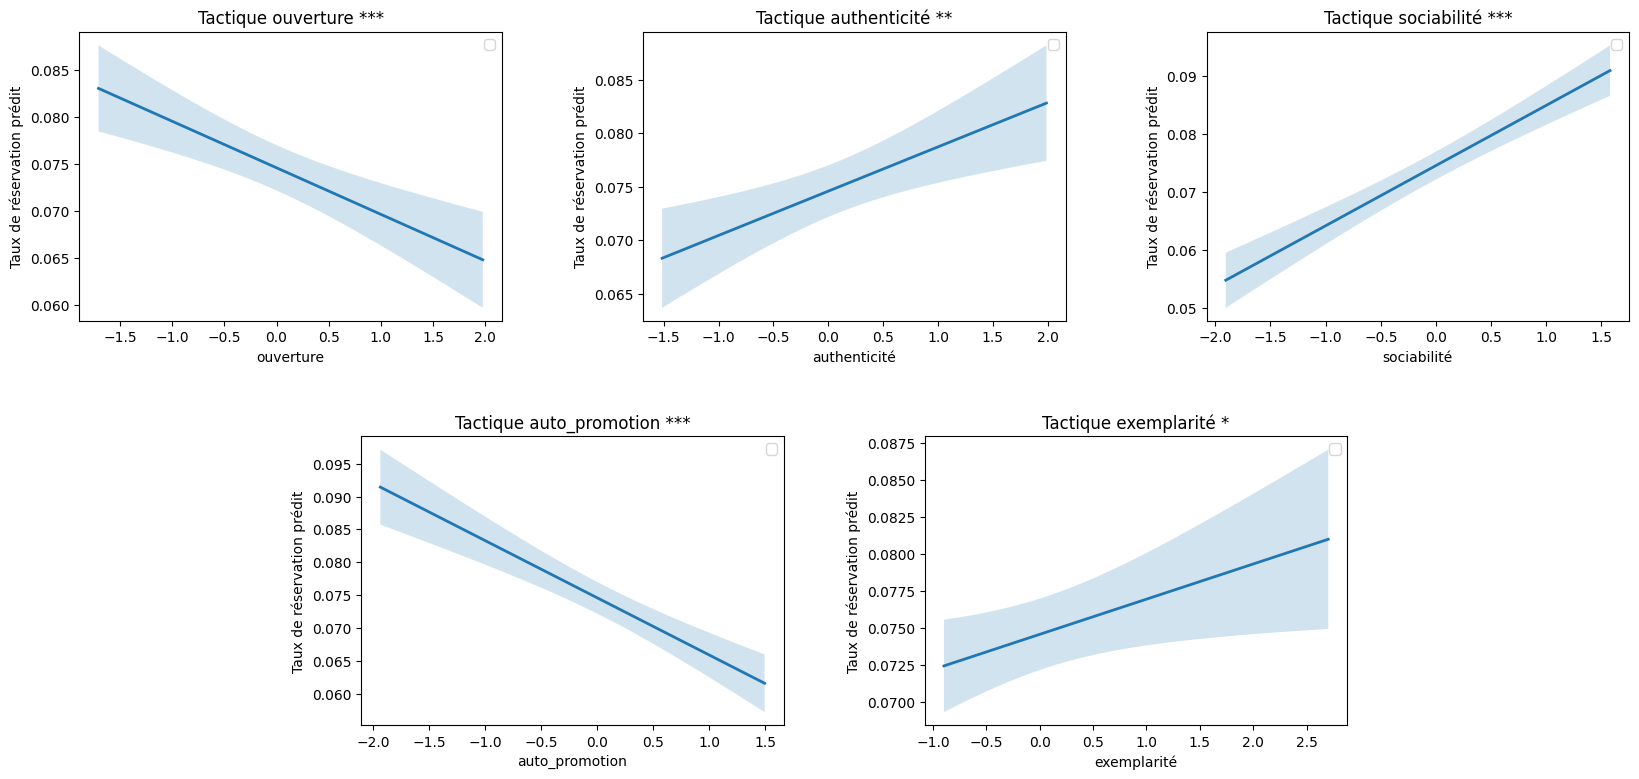

=========================================interaction plots==========================================
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ status_changed * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ status_changed * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + profe

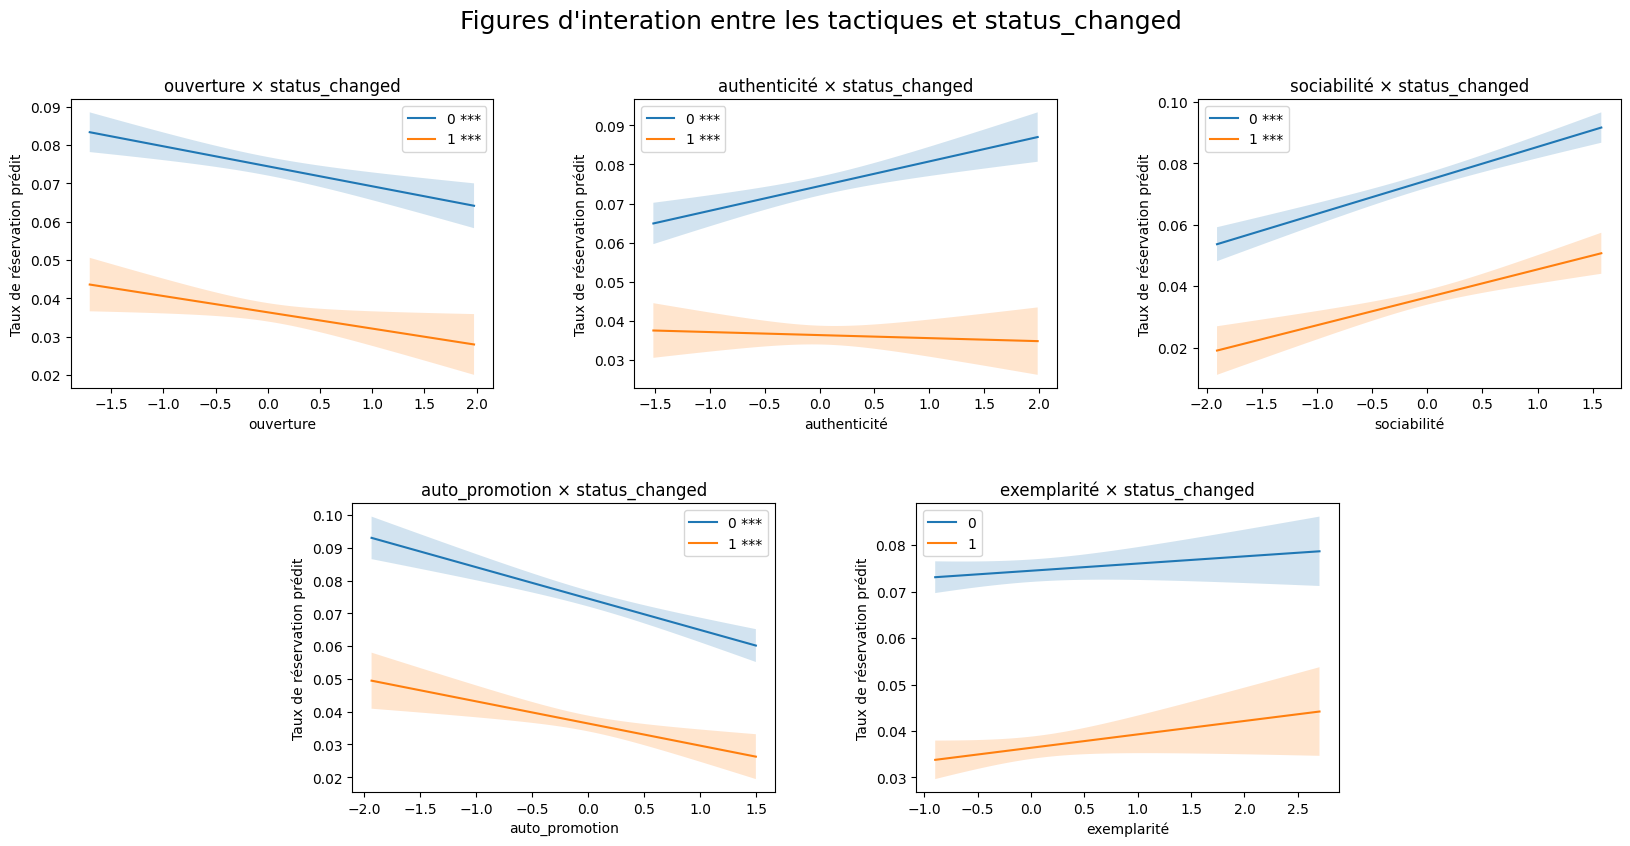

In [ ]:

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    'status_changed',
    # 'old_host_sp_changed',
    # "is_changed",
    # "city",
    "lang", "len",
    "price", 
    "availability_90","room_type", "instant_bookable", #'is_within_1km',#"city"
]  
modeling_main(df_input=df_paris, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col='status_changed',
            output_folder=None,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )

## status/sp_changed交互时，均只有authenticity有显著差异
##==> 是否改变影响不大？

## city

=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================

 ============================================basic model============================================= 

[NUMBER CHECK1] x_vars:12, x_vars_ctrl:12
['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable', 'booking_rate_l90d']
-key_vars ; - group_cols
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(roo

,host_is_superhost,ouverture,is_base,coef,se,t,pval,sig
0,f,1,True,-0.003961,0.001327,-2.985523,0.002832,**
1,t,1,False,-0.008323,0.002193,-3.794985,0.000148,***


authenticité


,host_is_superhost,authenticité,is_base,coef,se,t,pval,sig
0,f,1,True,0.003110,0.001483,2.096826,0.036013,*
1,t,1,False,0.006848,0.002426,2.822467,0.004767,**


sociabilité


...

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:984: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


+key_vars ; - group_cols
remove key_vars in x_vars
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:984: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


+key_vars ; - group_cols
remove key_vars in x_vars
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:984: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


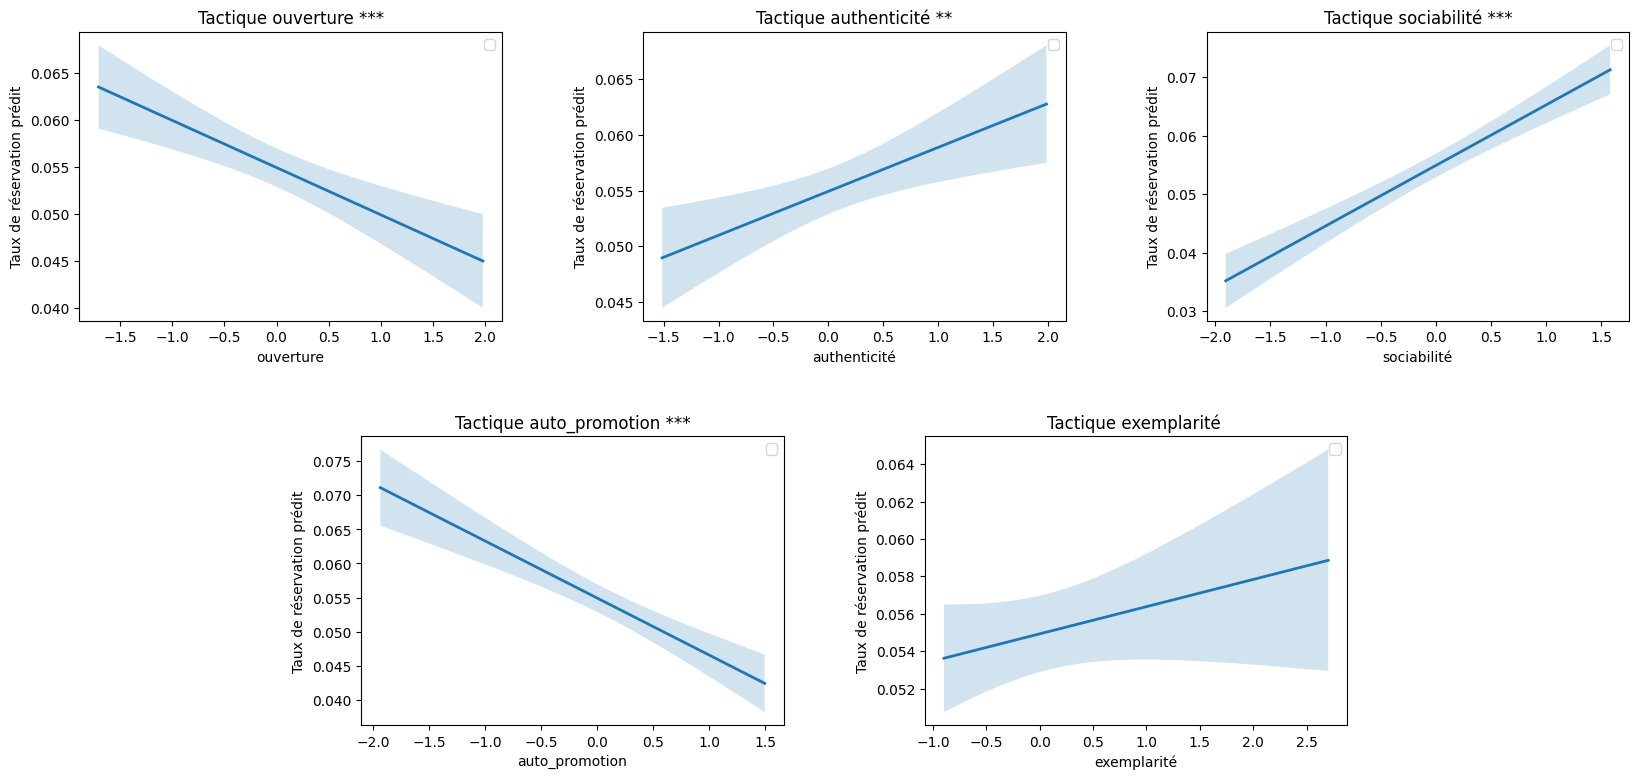

=========================================interaction plots==========================================
+key_vars ; + group_cols
remove key_vars in x_vars
LIST group_col:['host_is_superhost']
remove group_col in x_vars
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

group col str:  C(host_is_superhost)*
key_vars_f: ouverture + authenticité + sociabilité + auto_promotion + exemplarité + C(host_is_superhost)* (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité + C(host_is_superhost)* (ouverture + authenticité + so

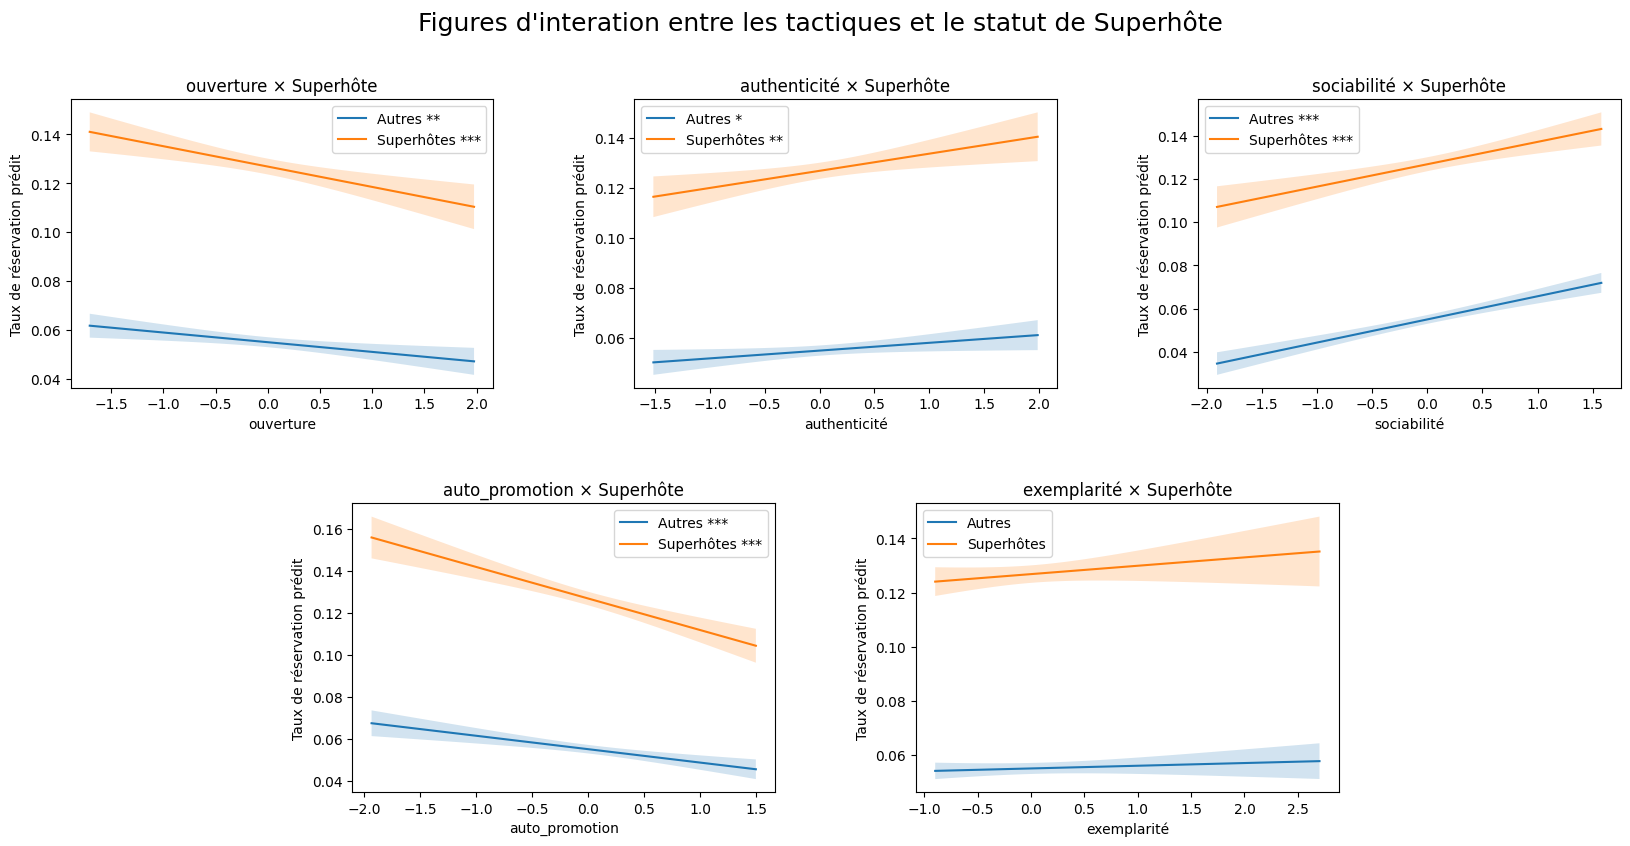

In [9]:
import os, sys, importlib
sys.path.append(os.path.abspath(".."))
import pandas as pd
from utils import modeling
importlib.reload(modeling)
from utils.modeling import modeling_main,build_model

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',"is_changed",
    # "city",
    "lang", "len",
    "price", 
    "availability_90","room_type", "instant_bookable", #'is_within_1km'
]  

tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité",
              ]

modeling_main(df_input=df_paris, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col="host_is_superhost",
            output_folder=None,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )

=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================

 ============================================basic model============================================= 

[NUMBER CHECK1] x_vars:12, x_vars_ctrl:12
['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable', 'booking_rate_l90d']
-key_vars ; - group_cols
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(roo

,host_is_superhost,ouverture,is_base,coef,se,t,pval,sig
0,f,1,True,0.003437,0.001700,2.022291,0.043152,*
1,t,1,False,-0.002848,0.002514,-1.132835,0.257289,


authenticité


,host_is_superhost,authenticité,is_base,coef,se,t,pval,sig
0,f,1,True,-0.004938,0.001915,-2.577892,9.943337e-03,**
1,t,1,False,0.018430,0.002663,6.919520,4.586348e-12,***


sociabilité


...

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:984: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


+key_vars ; - group_cols
remove key_vars in x_vars
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:984: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


+key_vars ; - group_cols
remove key_vars in x_vars
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:984: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


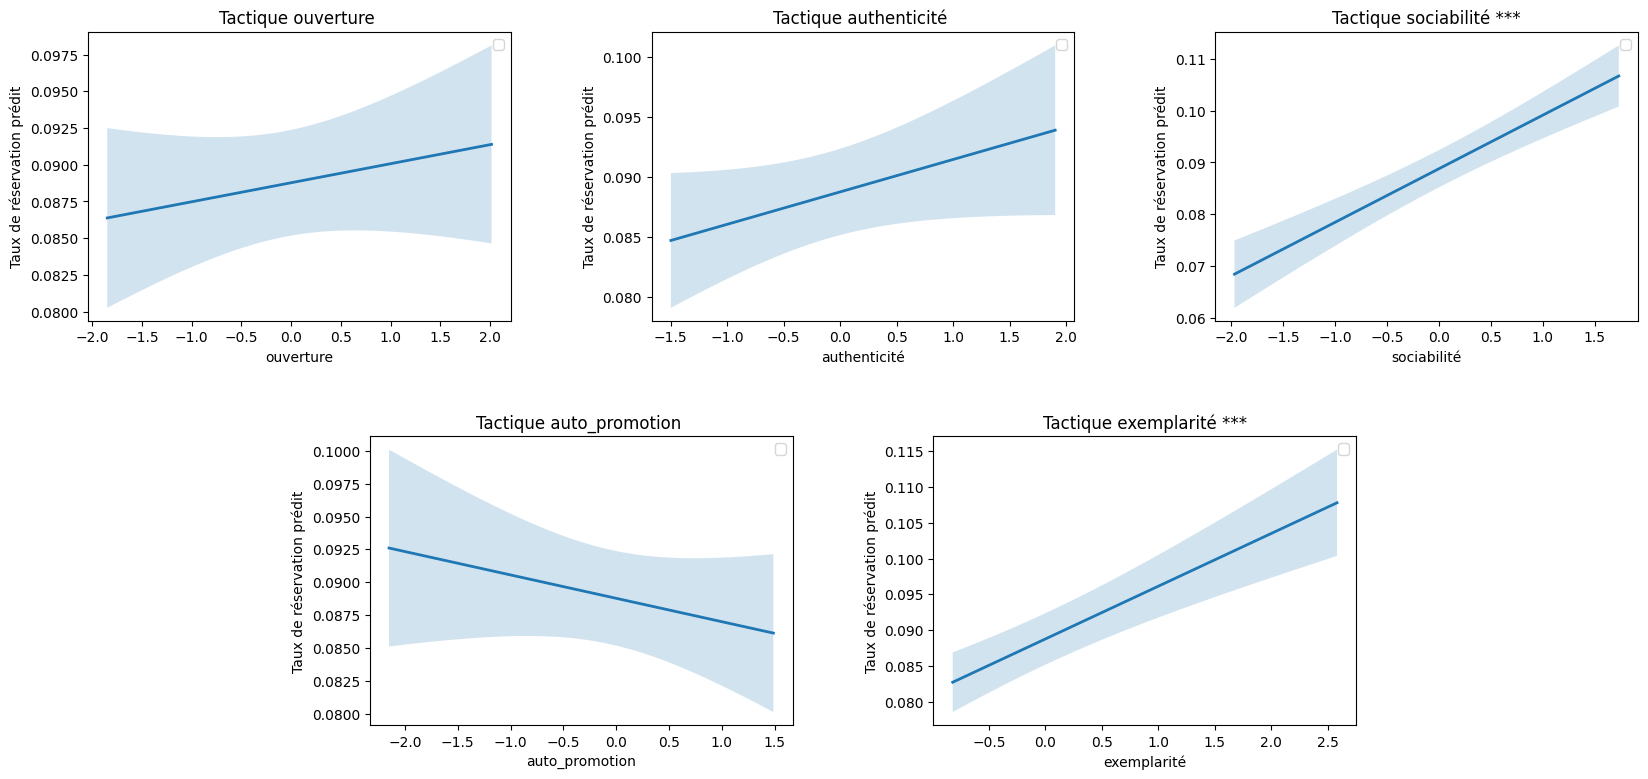

=========================================interaction plots==========================================
+key_vars ; + group_cols
remove key_vars in x_vars
LIST group_col:['host_is_superhost']
remove group_col in x_vars
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

group col str:  C(host_is_superhost)*
key_vars_f: ouverture + authenticité + sociabilité + auto_promotion + exemplarité + C(host_is_superhost)* (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité + C(host_is_superhost)* (ouverture + authenticité + so

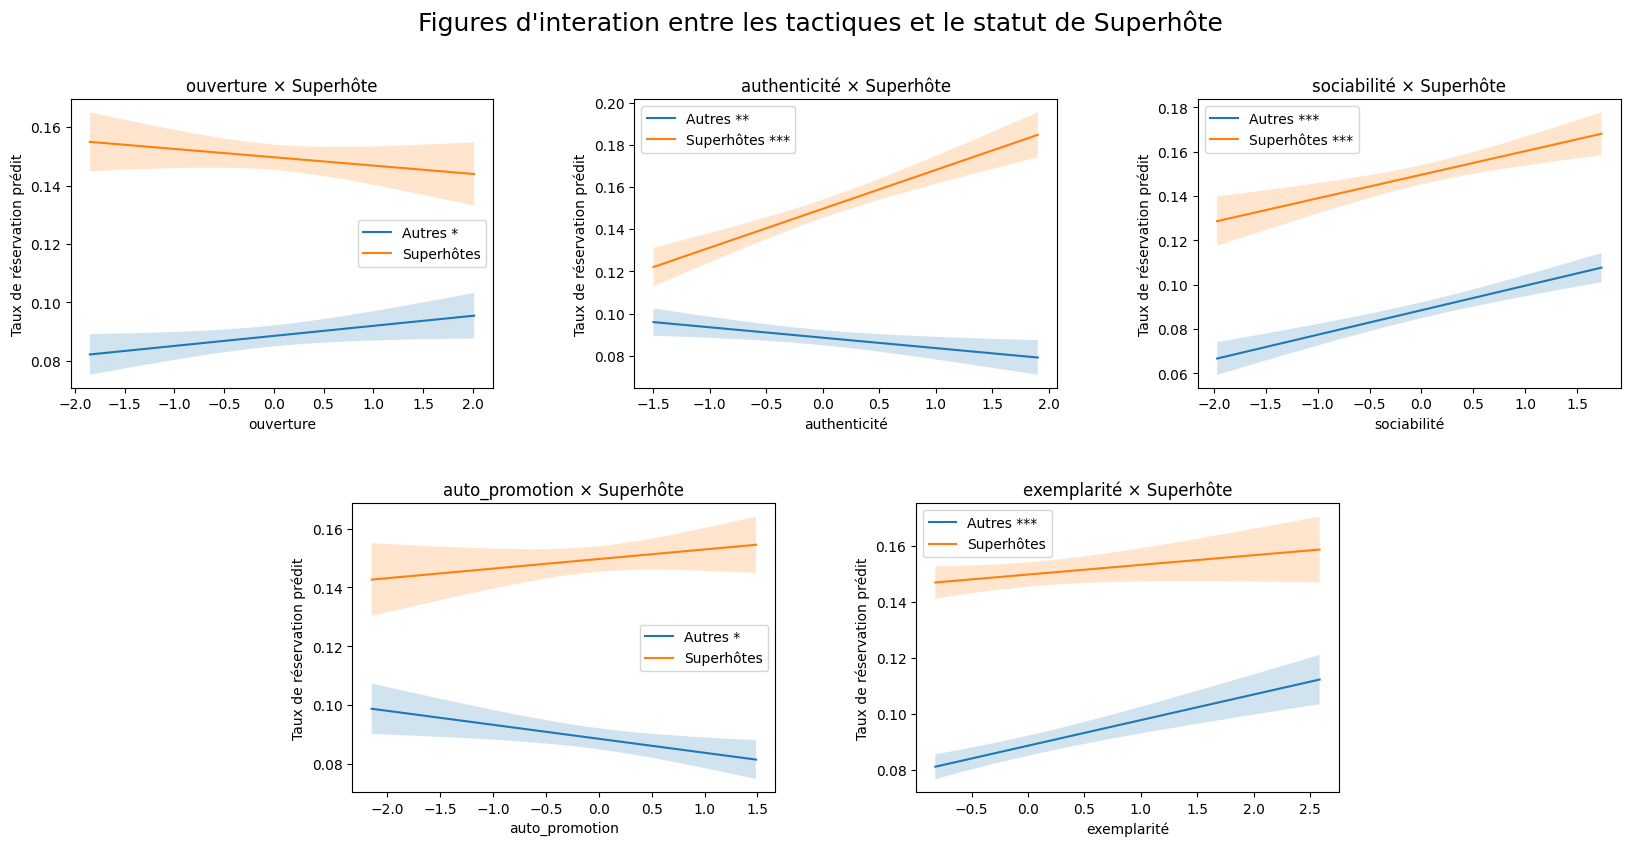

In [8]:
# london
x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',"is_changed",
    # "city",
    "lang", "len",
    "price", 
    "availability_90","room_type", "instant_bookable", #'is_within_1km'
]  

tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité",
              ]

modeling_main(df_input=df_london, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col='host_is_superhost',
            output_folder=None,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )

### all

In [13]:
# importlib.reload(modeling)
# from utils.modeling import modeling_main, write_formula, build_model, get_booking_rate_l30d

# x_vars=["host_identity_verified", "host_has_profile_pic",         
#     "review_scores_rating", #"has_rating", "number_of_reviews",
#     "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
#     'status_changed', 
#     # 'old_host_sp_changed',
#     # "is_changed",
#     "city",
#     "lang", "len",
#     "price", 
#     "availability_90","room_type", "instant_bookable", #'is_within_1km'
# ]  

# key_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", "host_is_superhost"]

# df, formula, model_tactics=build_model (df_input=df_all,
#         x_vars=x_vars, 
#         key_vars=key_vars, 
#         to_fillna0=True,
#         y_var='booking_rate_l90d', 
#         group_col='city', #*
#         # outpath_folder=output_folder, 
#         # tex_filename='ols_summary_tactics.tex', 
#         # save=save_models_summary
#         )

In [ ]:
# df_all['jo_entrant']=df_all.apply(lambda row: 1 if row["city"]=="paris" and row["status_changed"]==1 else 0 ,axis=1)
# print(df_all['jo_entrant'].value_counts(dropna=False))


jo_entrant
0    89775
1    22819
Name: count, dtype: int64


=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================

 ============================================basic model============================================= 

[NUMBER CHECK1] x_vars:14, x_vars_ctrl:14
['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'status_changed', 'city', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable', 'booking_rate_l90d']
-key_vars ; - group_cols
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'status_changed', 'city', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_p

,city,ouverture,is_base,coef,se,t,pval,sig
0,paris,1,False,-0.004149,0.001288,-3.220586,0.00128,**
1,london,1,True,0.001163,0.001255,0.927151,0.35385,


authenticité


,city,authenticité,is_base,coef,se,t,pval,sig
0,paris,1,False,0.001428,0.001425,1.001608,0.316535,
1,london,1,True,0.006530,0.001383,4.721968,0.000002,***


sociabilité


...

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:984: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


+key_vars ; - group_cols
remove key_vars in x_vars
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'status_changed', 'city', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(city) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:984: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


+key_vars ; - group_cols
remove key_vars in x_vars
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'status_changed', 'city', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(city) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:984: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


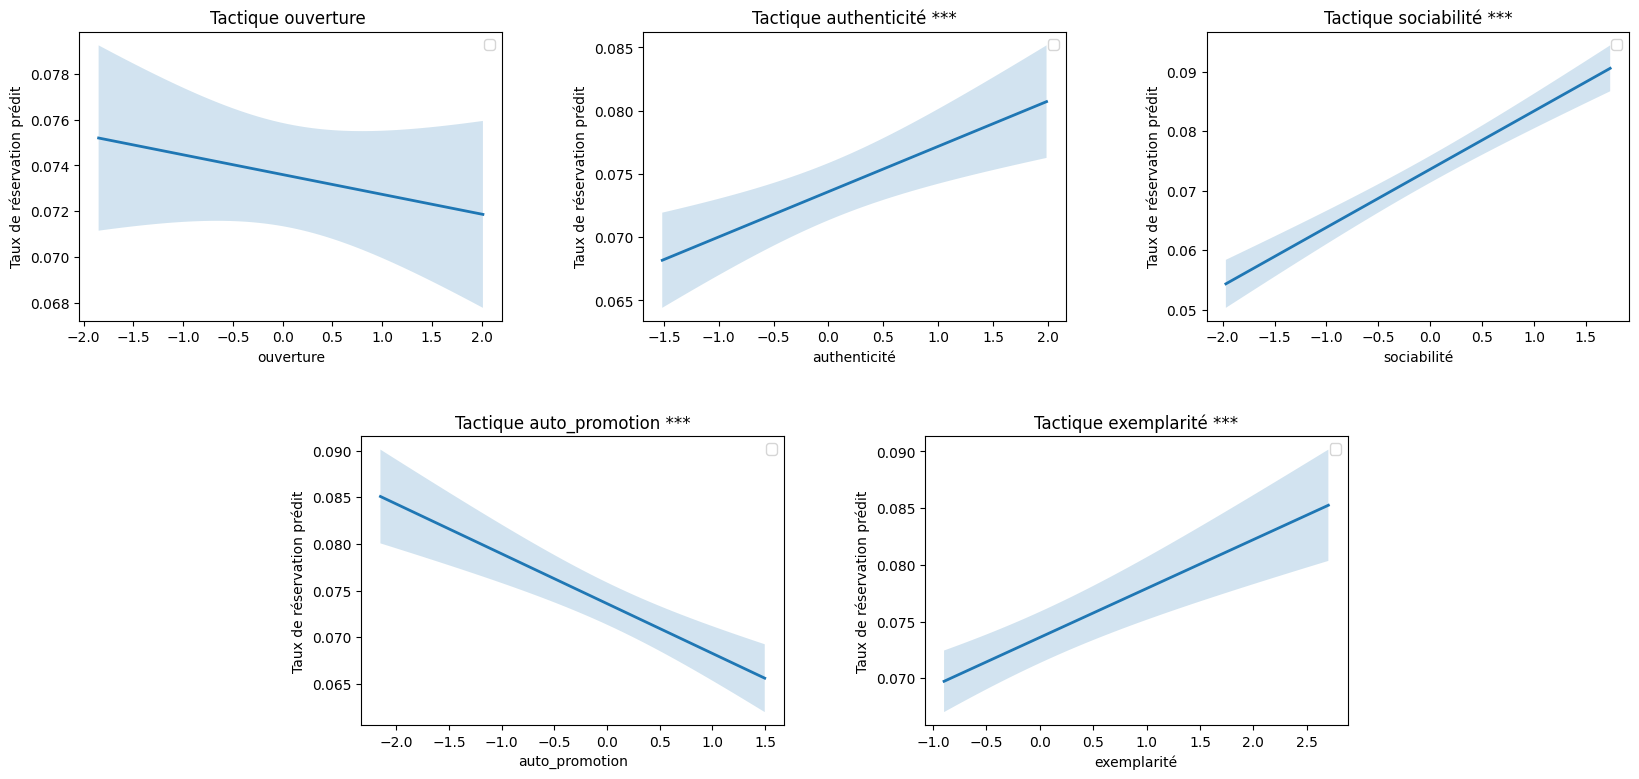

=========================================interaction plots==========================================
+key_vars ; + group_cols
remove key_vars in x_vars
LIST group_col:['city']
remove group_col in x_vars
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'status_changed', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

group col str:  C(city)*
key_vars_f: ouverture + authenticité + sociabilité + auto_promotion + exemplarité + C(city)* (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité + C(city)* (ou

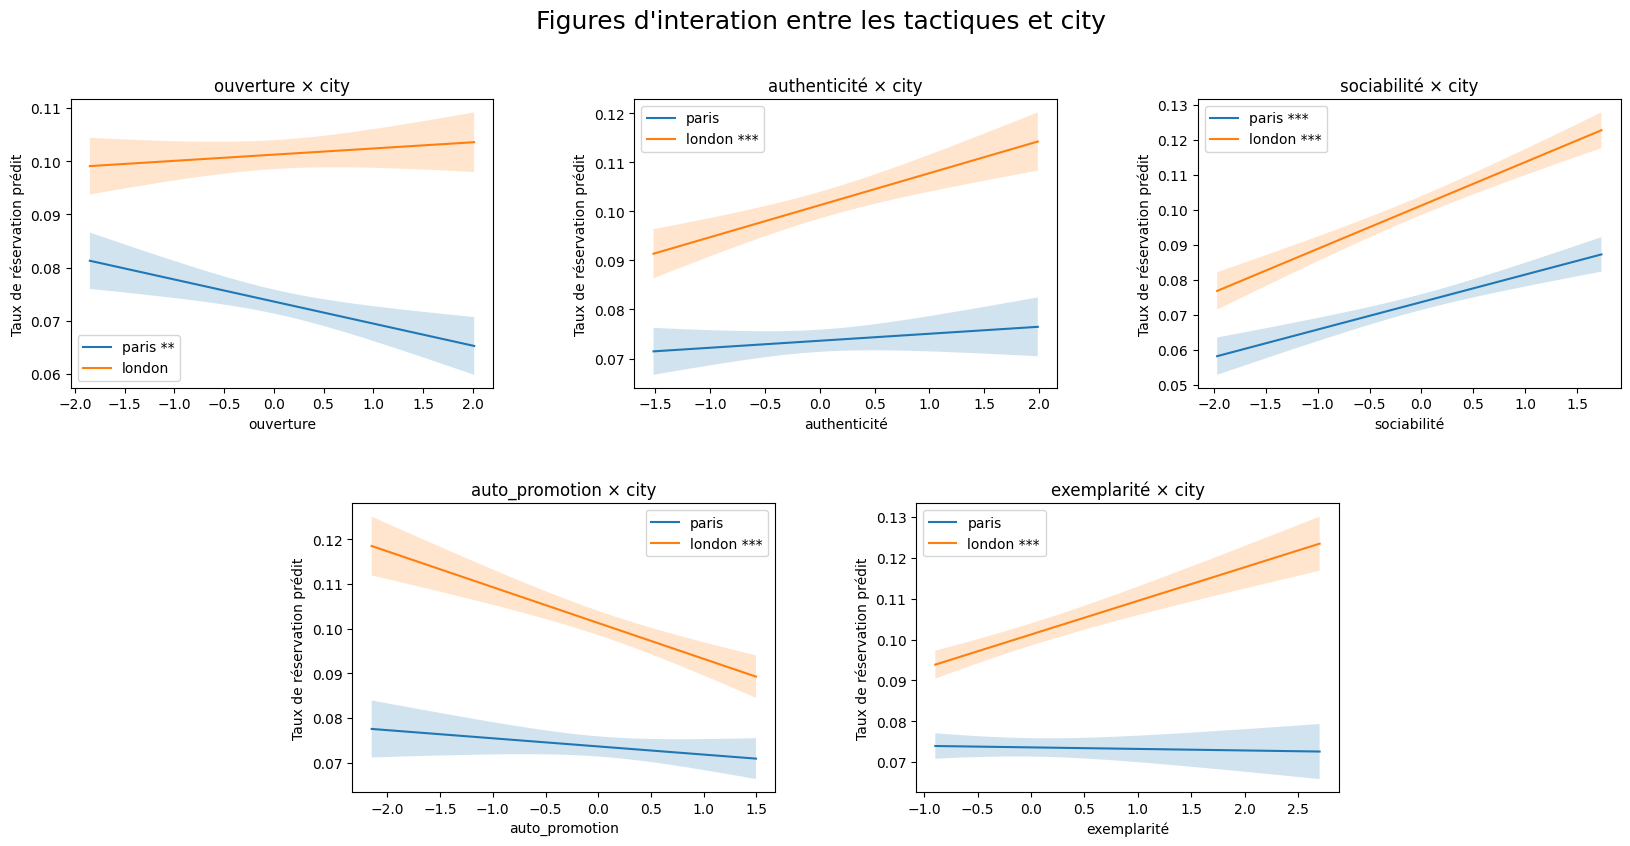

In [17]:
importlib.reload(modeling)
from utils.modeling import modeling_main, write_formula, build_model, get_booking_rate_l30d

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    'status_changed', 
    # 'old_host_sp_changed',
    # "is_changed",
    "city",
    "lang", "len",
    "price", 
    "availability_90","room_type", "instant_bookable", #'is_within_1km'
]  

tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité",
            #   "host_is_superhost"
              ]

modeling_main(df_input=df_all, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col='city',#==jo
            output_folder=None,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )


In [69]:
importlib.reload(modeling)
from utils.modeling import modeling_main, get_booking_rate_l30d

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    'status_changed', 
    # 'old_host_sp_changed',
    # "is_changed",
    "city",
    "lang", "len",
    "price", 
    "availability_90","room_type", "instant_bookable", #'is_within_1km'
]  

tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]

modeling_main(df_input=df_all, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col=['city','host_is_superhost'],#==jo
            output_folder=None,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )

=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================

 ============================================basic model============================================= 

[NUMBER CHECK1] x_vars:14, x_vars_ctrl:14
[CHECK] isna False in all 15 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  host_is_superhost  status_changed  city   lang   len    price  availability_90  room_type  instant_bookable  booking_rate_l90d
False                   False                 False                 False             False              False              False           False  False  False  False  False            False      False             False                112594
Name: count, dtype: int64

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_

AttributeError: 'DataFrame' object has no attribute 'unique'

=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================

 ============================================basic model============================================= 

[NUMBER CHECK1] x_vars:14, x_vars_ctrl:14
[CHECK] isna False in all 15 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  host_is_superhost  status_changed  city   lang   len    price  availability_90  room_type  instant_bookable  booking_rate_l90d
False                   False                 False                 False             False              False              False           False  False  False  False  False            False      False             False                25106
Name: count, dtype: int64

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_p

,is_base,coef,se,t,pval,sig
paris,False,-0.005265,0.003285,-1.602839,0.108983,
london,True,-0.002534,0.002834,-0.894101,0.371276,


authenticité
x paris/london


,is_base,coef,se,t,pval,sig
paris,False,-0.007409,0.003551,-2.086411,0.036952,*
london,True,0.010992,0.003028,3.630519,0.000283,***


sociabilité
x paris/london


...


 ============================================models table============================================


,Basique,Tactiques,city
C(city)[T.paris],-0.0232***\n(0.0032),-0.0232***\n(0.0032),-0.0220***\n(0.0033)
ouverture,,,-0.0025\n(0.0028)
C(city)[T.paris]:ouverture,,,-0.0027\n(0.0043)
authenticité,,,0.0110***\n(0.0030)
C(city)[T.paris]:authenticité,,,-0.0184***\n(0.0046)
sociabilité,,,0.0081***\n(0.0030)
C(city)[T.paris]:sociabilité,,,-0.0030\n(0.0044)
auto_promotion,,,0.0046\n(0.0032)
C(city)[T.paris]:auto_promotion,,,-0.0071\n(0.0047)
exemplarité,,,0.0025\n(0.0025)


,Basique,Tactiques,city
C(host_identity_verified)[T.t],0.0201**\n(0.0085),0.0201**\n(0.0085),0.0190**\n(0.0085)
C(host_has_profile_pic)[T.t],0.0135\n(0.0108),0.0135\n(0.0108),0.0136\n(0.0108)
C(lang)[T.fr],0.0173***\n(0.0046),0.0173***\n(0.0046),0.0178***\n(0.0051)
C(lang)[T.no_text],0.0010\n(0.0035),0.0010\n(0.0035),0.0008\n(0.0036)
C(lang)[T.other_langs],-0.0142\n(0.0117),-0.0142\n(0.0117),-0.0122\n(0.0117)
C(room_type)[T.Hotel room],-0.0698***\n(0.0182),-0.0698***\n(0.0182),-0.0754***\n(0.0182)
C(room_type)[T.Private room],0.0533***\n(0.0032),0.0533***\n(0.0032),0.0513***\n(0.0033)
C(room_type)[T.Shared room],0.0548**\n(0.0275),0.0548**\n(0.0275),0.0521*\n(0.0275)
C(instant_bookable)[T.t],0.0201***\n(0.0031),0.0201***\n(0.0031),0.0201***\n(0.0031)
review_scores_rating,0.0383***\n(0.0082),0.0383***\n(0.0082),0.0377***\n(0.0082)


===========================================tactics plots============================================
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(city) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



PatsyError: predict requires that you use a DataFrame when predicting from a model
that was created using the formula api.

The original error message returned by patsy is:
Error evaluating factor: NameError: name 'host_is_superhost' is not defined
    booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(city) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ openness + authenticity + sociability + self_promotion + exemplification
                                                                              ^^^^^^^^^^^^^^^^^^^^

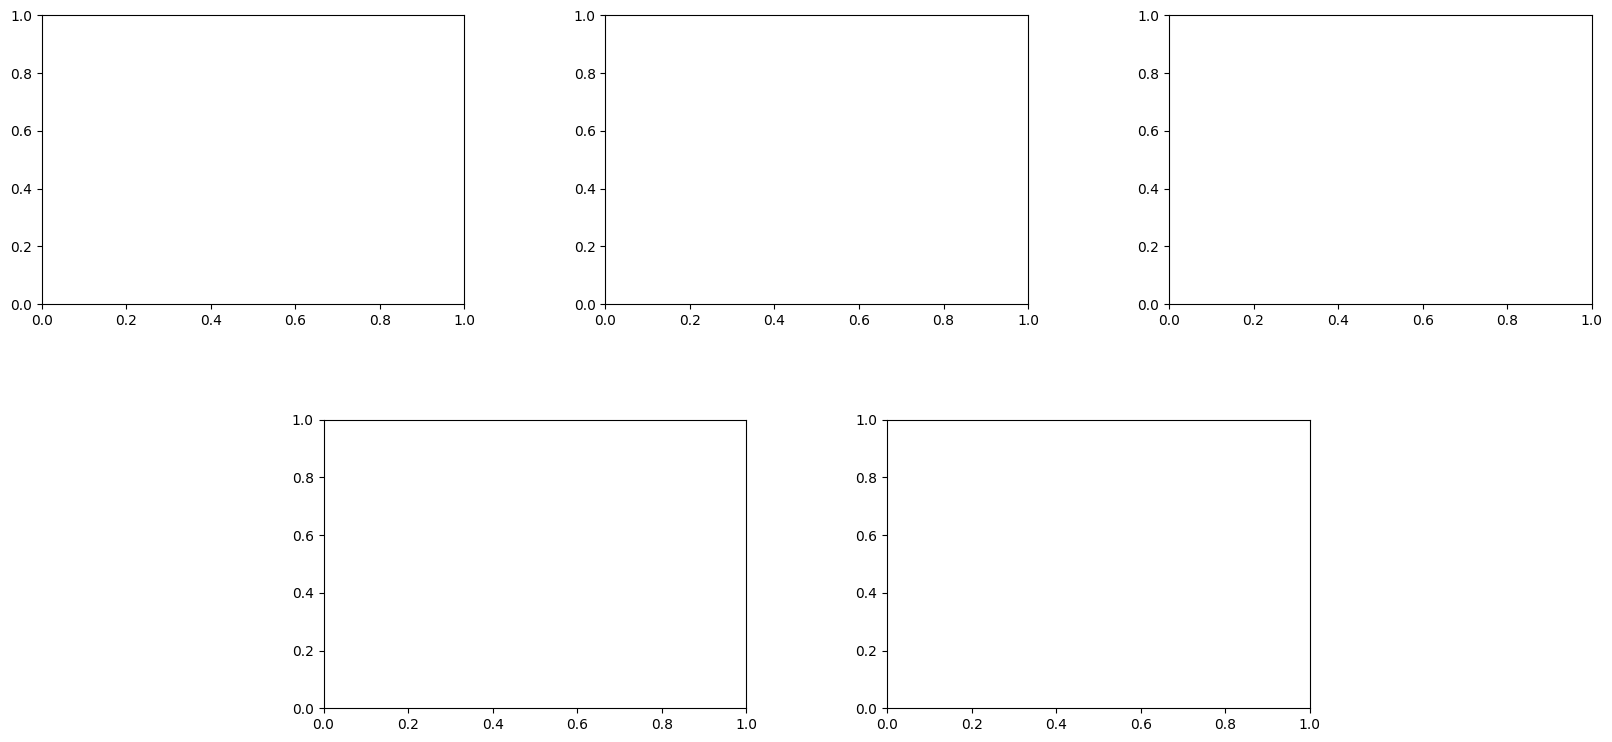

In [73]:
df_all_superhost=df_all[df_all['host_is_superhost']=="t"]

modeling_main(df_input=df_all_superhost, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col='city',#==jo
            output_folder=None,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )

In [70]:

modeling_main(df_input=df_all, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col=['city','status_changed'],#==jo
            output_folder=None,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )

=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================

 ============================================basic model============================================= 

[NUMBER CHECK1] x_vars:14, x_vars_ctrl:14
[CHECK] isna False in all 15 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  host_is_superhost  status_changed  city   lang   len    price  availability_90  room_type  instant_bookable  booking_rate_l90d
False                   False                 False                 False             False              False              False           False  False  False  False  False            False      False             False                112594
Name: count, dtype: int64

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_

AttributeError: 'DataFrame' object has no attribute 'unique'

In [45]:
importlib.reload(modeling)
from utils.modeling import modeling_main, get_booking_rate_l30d

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    'status_changed', 
    # 'old_host_sp_changed',
    # "is_changed",
    "city",
    "lang", "len",
    "price", 
    "availability_90","room_type", "instant_bookable", #'is_within_1km'
]  

tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]

modeling_main(df_input=df_all, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col=['city',"is_changed"],#==jo
            output_folder=None,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )


=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================

 ============================================basic model============================================= 

[NUMBER CHECK1] x_vars:14, x_vars_ctrl:14
[CHECK] isna False in all 15 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  host_is_superhost  status_changed  city   lang   len    price  availability_90  room_type  instant_bookable  booking_rate_l90d
False                   False                 False                 False             False              False              False           False  False  False  False  False            False      False             False                112594
Name: count, dtype: int64

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_

AttributeError: 'DataFrame' object has no attribute 'unique'

In [42]:
# ols mod
import statsmodels.api as sm
import statsmodels.formula.api as smf
importlib.reload(modeling)
from utils.modeling import write_formula

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    # 'status_changed', 
    # 'old_host_sp_changed',
    # "is_changed",
    "city",
    "lang", "len",
    "price", 
    "availability_90","room_type", "instant_bookable", #'is_within_1km'
]  

tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]


f= write_formula(df=df_all, 
                 x_vars=x_vars, 
                 y_var="booking_rate_l90d", 
                 key_vars=tactics_vars,
                #  group_col="city", 
                 group_col=["city","status_changed"]
                )


LIST group_col:['city', 'status_changed']
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ + C(city) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité) + status_changed * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)



=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================

 ============================================basic model============================================= 

[NUMBER CHECK1] x_vars:13, x_vars_ctrl:13
[CHECK] isna False in all 14 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  host_is_superhost  city   lang   len    price  availability_90  room_type  instant_bookable  booking_rate_l90d
False                   False                 False                 False             False              False              False  False  False  False  False            False      False             False                30245
Name: count, dtype: int64

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(c

,is_base,coef,se,t,pval,sig
paris,False,-0.004175,0.002212,-1.886998,0.05917,
london,True,-0.002654,0.003293,-0.805961,0.420272,


authenticité
x paris/london


,is_base,coef,se,t,pval,sig
paris,False,-0.00134,0.002409,-0.556254,0.578041,
london,True,0.004192,0.003532,1.186685,0.235361,


sociabilité
x paris/london


...

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:696: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(city) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:696: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(city) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:696: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


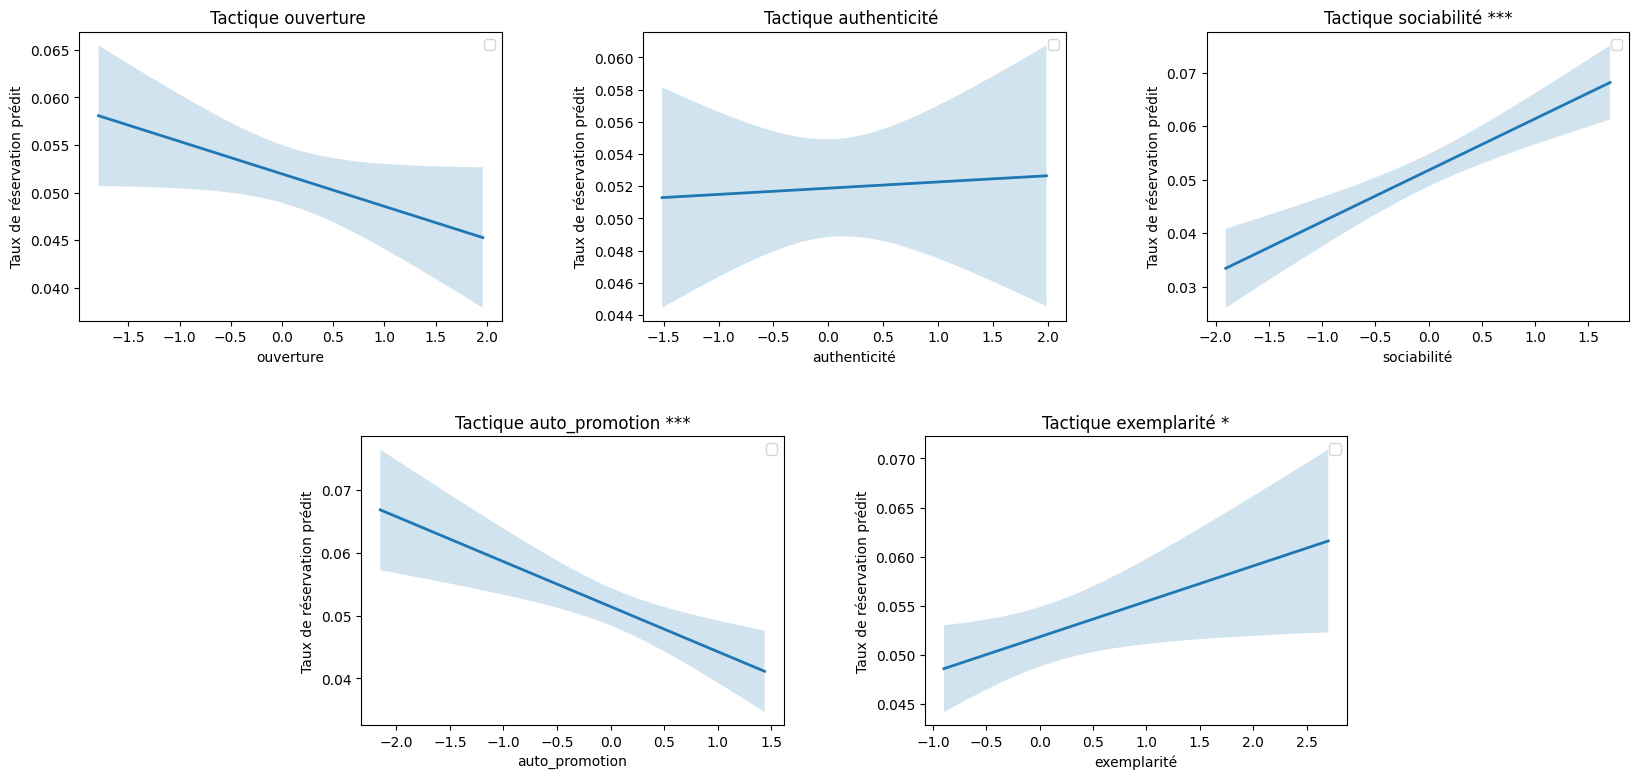

=========================================interaction plots==========================================
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ C(city) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ C(city) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host +

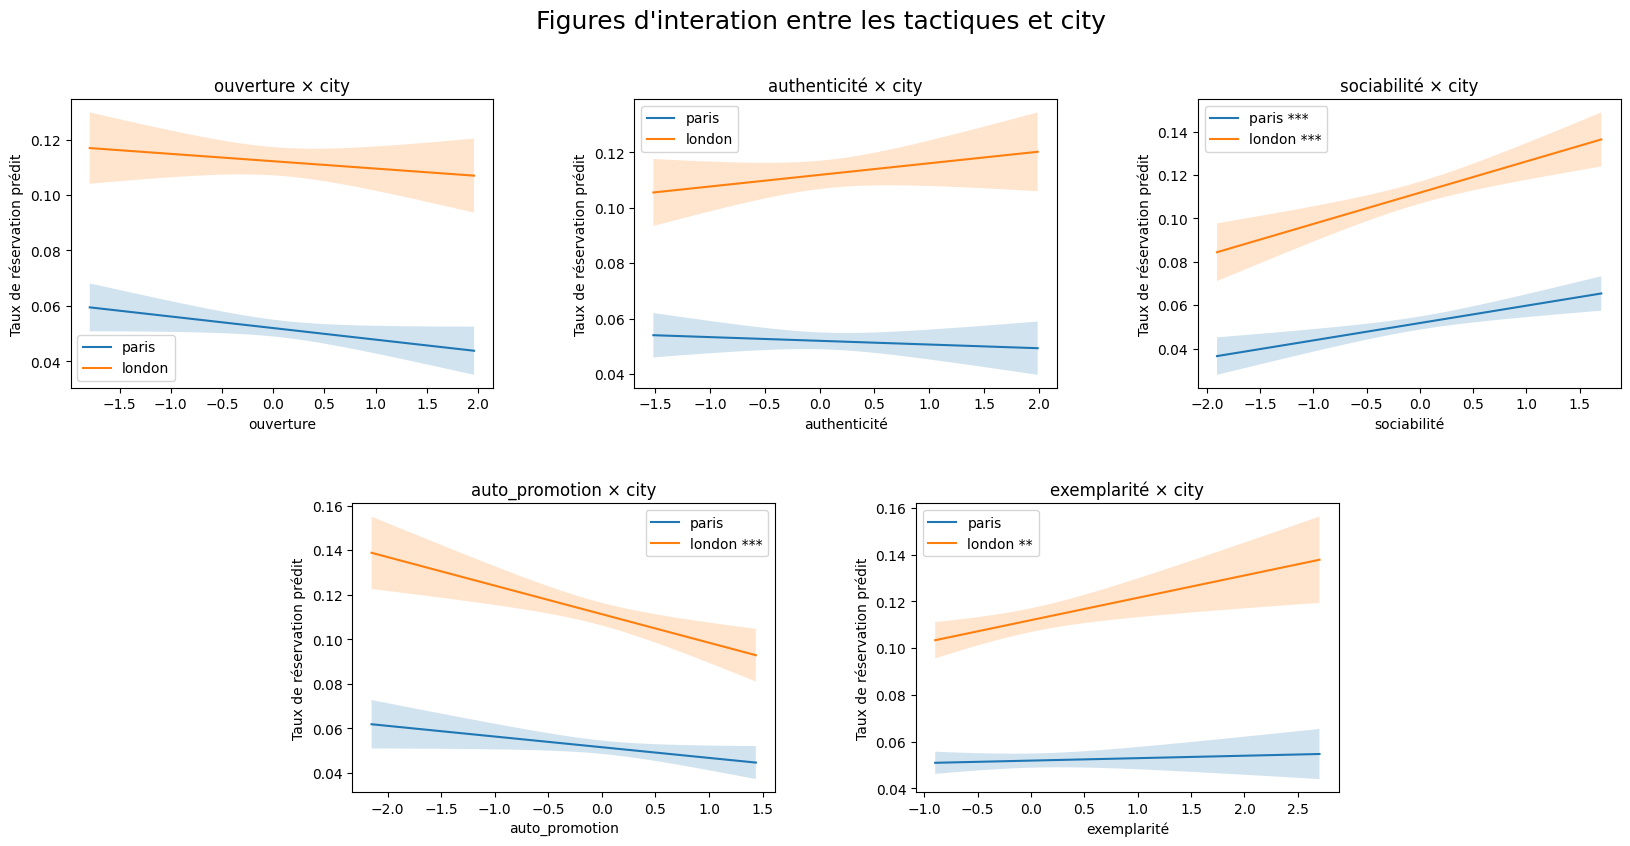

In [21]:
df_all_changed=df_all[df_all["status_changed"]==1]

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    # 'status_changed', 
    #'old_host_sp_changed',
    # "is_changed",
    "city",
    "lang", "len",
    "price", 
    "availability_90","room_type", "instant_bookable", #'is_within_1km',#"city"
]  

modeling_main(df_input=df_all_changed, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col='city',#==jo
            output_folder=None,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )

In [19]:
# modeling_main(df_input=df_all, 
#             x_vars=x_vars, 
#             y_var="booking_rate_l90d", 
#             key_vars=tactics_vars, 
#             group_col=["city","status_changed"],#'city',#==jo
#             output_folder=None,
#             to_fillna0=True,
#             run_vif=False,
#             # save_models_summary=False,  
#             save_models_table=False,
#             save_plots=False,
#             ndigits=4
#         )
# # 三重交互 city*tactics*status_changed均不显著

=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================

 ============================================basic model============================================= 

[NUMBER CHECK1] x_vars:14, x_vars_ctrl:14
[CHECK] isna False in all 15 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  host_is_superhost  status_changed  city   lang   len    price  availability_90  room_type  instant_bookable  booking_rate_l90d
False                   False                 False                 False             False              False              False           False  False  False  False  False            False      False             False                30245
Name: count, dtype: int64

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_p

,is_base,coef,se,t,pval,sig
paris,False,-0.004175,0.002212,-1.886998,0.05917,
london,True,-0.002654,0.003293,-0.805961,0.420272,


authenticité
x paris/london


,is_base,coef,se,t,pval,sig
paris,False,-0.00134,0.002409,-0.556254,0.578041,
london,True,0.004192,0.003532,1.186685,0.235361,


sociabilité
x paris/london


...

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:695: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(city) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:695: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(city) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:695: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


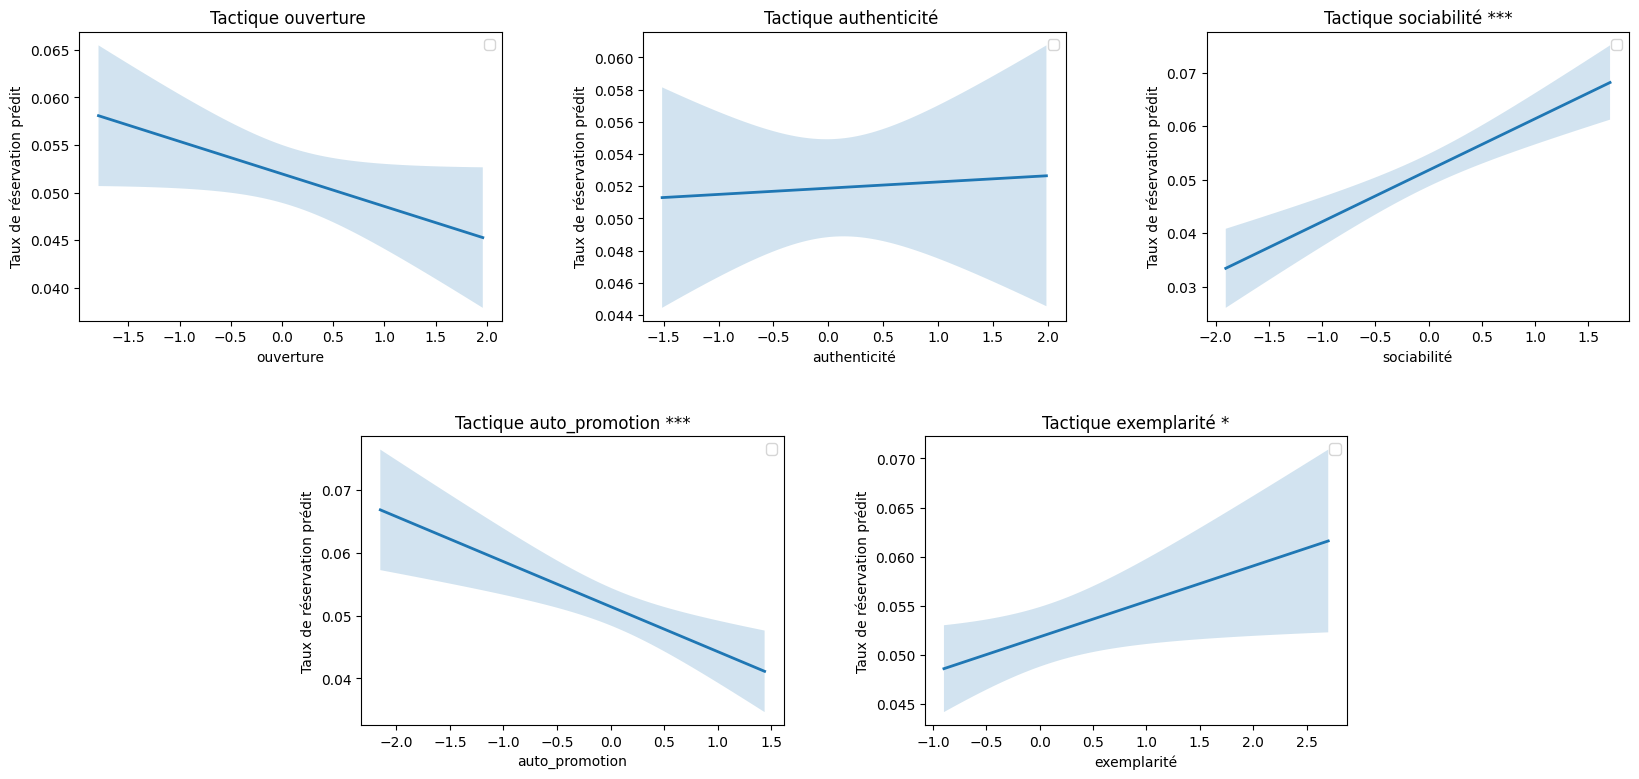

=========================================interaction plots==========================================
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ C(city) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ C(city) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + year

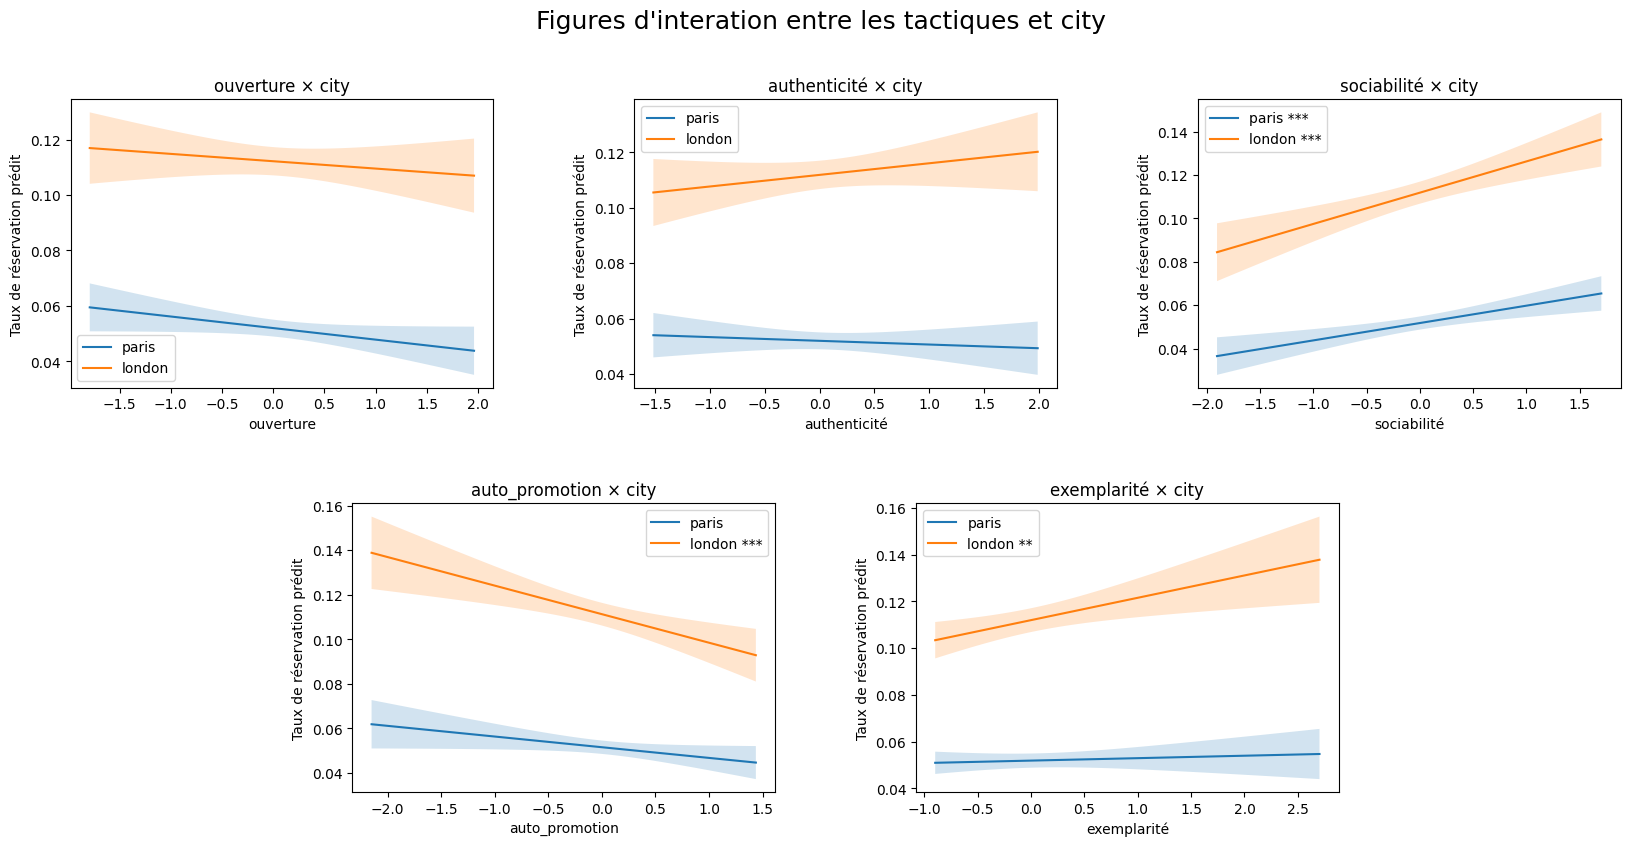

In [13]:
df_all_status_changed=df_all[df_all["status_changed"]==1]
modeling_main(df_input=df_all_status_changed, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col='city',#==jo
            output_folder=None,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )

=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================

 ============================================basic model============================================= 

[NUMBER CHECK1] x_vars:14, x_vars_ctrl:14
[CHECK] isna False in all 15 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  host_is_superhost  status_changed  city   lang   len    price  availability_90  room_type  instant_bookable  booking_rate_l90d
False                   False                 False                 False             False              False              False           False  False  False  False  False            False      False             False                82349
Name: count, dtype: int64

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_p

,is_base,coef,se,t,pval,sig
paris,False,-0.004711,0.00157,-3.000857,0.002693,**
london,True,0.001406,0.00136,1.033758,0.301252,


authenticité
x paris/london


,is_base,coef,se,t,pval,sig
paris,False,0.003767,0.001748,2.154926,0.03117,*
london,True,0.006007,0.001507,3.987101,0.000067,***


sociabilité
x paris/london


...

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:695: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(city) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:695: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(city) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:695: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


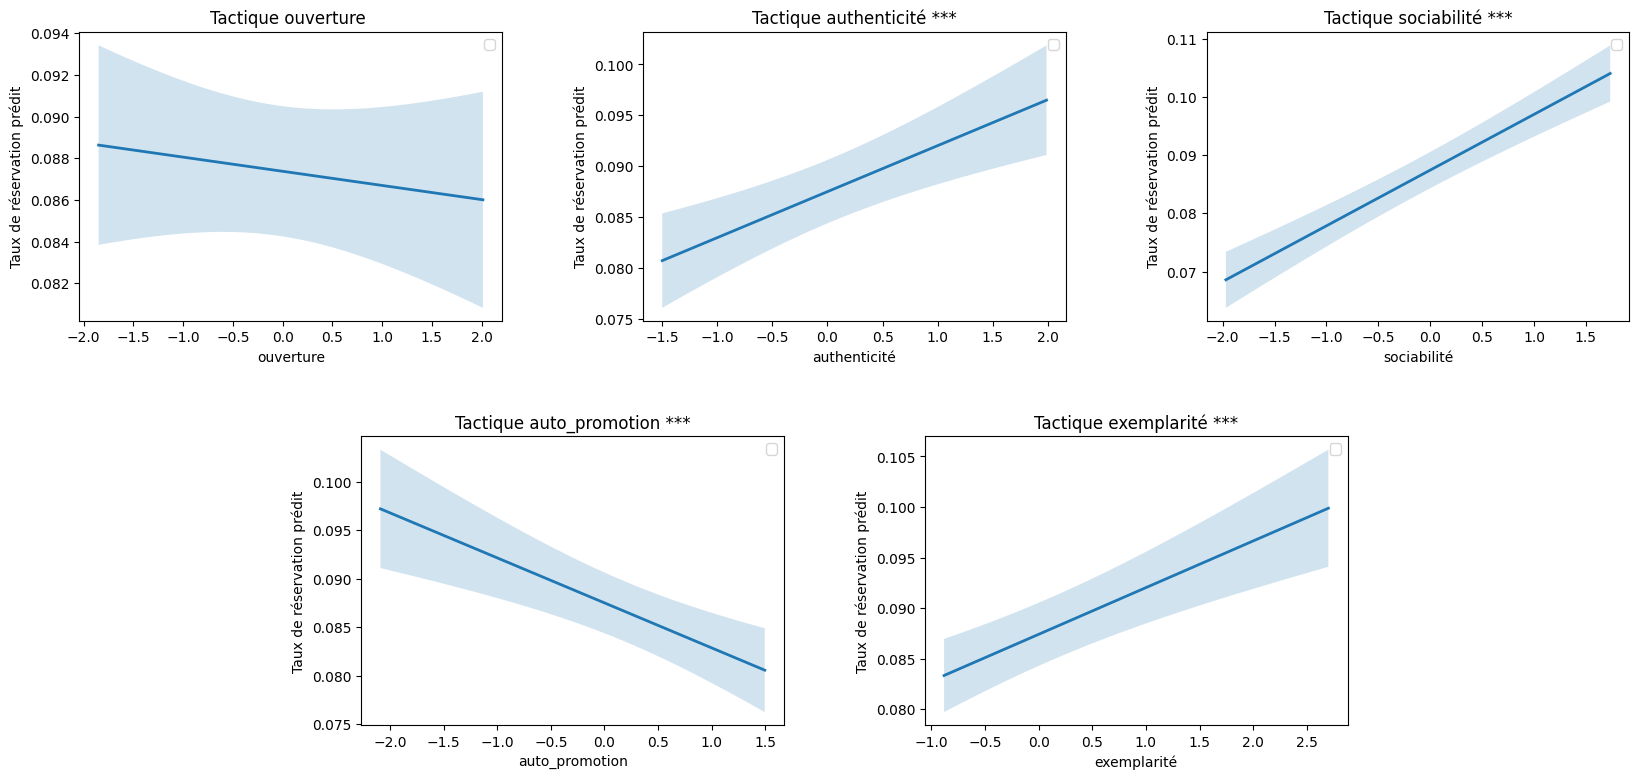

=========================================interaction plots==========================================
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ C(city) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ C(city) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + year

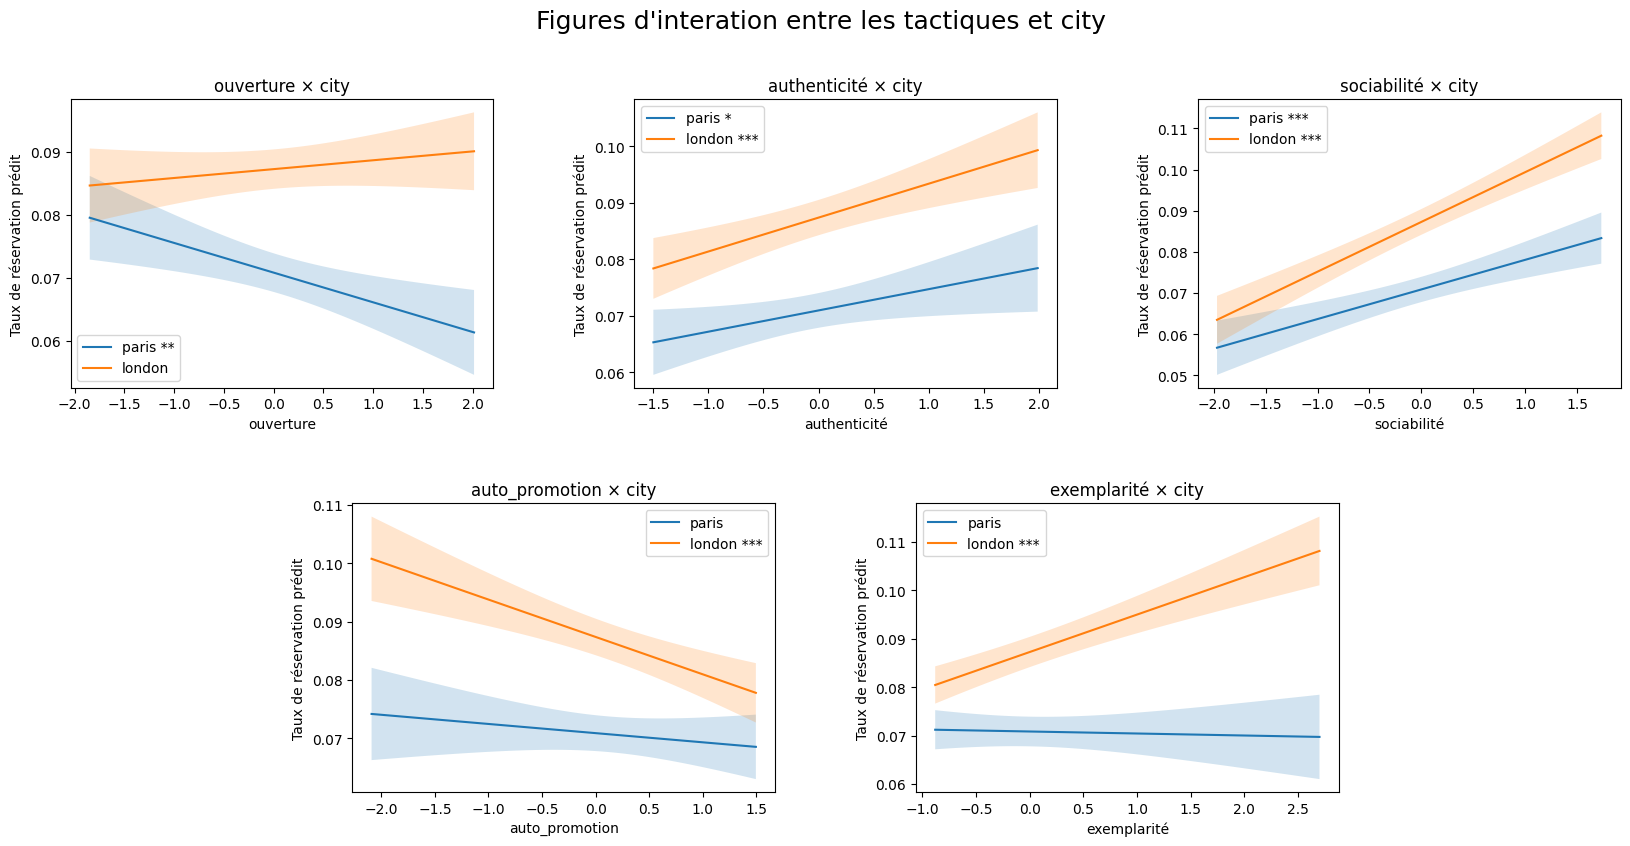

In [14]:
df_all_no_changed=df_all[df_all["status_changed"]==0]
modeling_main(df_input=df_all_no_changed, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col='city',#==jo
            output_folder=None,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )